In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import os
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import torch
import torch.optim as optim

from pathlib import Path
from PIL import Image
from torchvision import transforms

from UNet import UNet, UNetTrainer
from data import CarvanaDataset

In [ ]:
# Carvana

BATCH_SIZE = 1  
NUM_WORKERS = 4  # threads 2~8

data_root = "../../Data/Carvana_segmentation" 

os.environ['KAGGLE_API_TOKEN'] = 'YOUR_API_KEY'
path = kagglehub.competition_download(
    'carvana-image-masking-challenge', 
    output_dir=data_root
)

print(f"Dataset downloaded to: {path}")

for file in os.listdir(data_root):
    if file.endswith('.zip'):                     
        zip_path = os.path.join(data_root, file)
        extract_dir = os.path.join(data_root, os.path.splitext(file)[0])
        if os.path.exists(extract_dir):
            continue  
        os.makedirs(extract_dir, exist_ok=True)
        print(f"unziping {file}")   
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)     

In [6]:
train_hq_path=os.path.join(data_root,"train_hq","train_hq")
train_mask_zip_path=os.path.join(data_root,"train_masks","train_masks")
test_hq_path=os.path.join(data_root,"test_hq","test_hq")

dir_img = Path(train_hq_path)
dir_mask = Path(train_mask_zip_path)

train_set = CarvanaDataset(dir_img, dir_mask)

train_loader = torch.utils.data.DataLoader(
    dataset=train_set,        
    batch_size=BATCH_SIZE,    
    shuffle=True,             
    num_workers=NUM_WORKERS,  
    pin_memory=True,          # speeds up CPU-GPU batch transfer
    drop_last=False           
)

In [9]:
model_save_root = "../../Models/UNet"
os.makedirs(model_save_root,exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"

# UNet

#### Train

In [10]:
net=UNet(num_class=2)

lr=1e-5

optimizer = optim.Adam(net.parameters(), lr=lr)

trainer=UNetTrainer(model=net,
                       optimizer=optimizer,
                       dtype=float,
                       device=DEVICE)

trainer.train(num_epochs=5,
              train_dataloader=train_loader,
              log_interval=50)

torch.save(trainer.model.state_dict(),os.path.join(model_save_root,"UNet.pth"))

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/chenyifeng/.netrc.
wandb: Currently logged in as: 598061731 (my59) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING The get_url method is deprecated and will be removed in a future release. Please use `run.url` instead.


✅ WandB initialized. View at: https://wandb.ai/my59/UNet/runs/e6knb40l
📊 Check the experiment online: https://wandb.ai/my59/UNet/runs/e6knb40l
Iter: 0, Loss: 0.6773
Iter: 50, Loss: 0.3309
Iter: 100, Loss: 0.2323
Iter: 150, Loss: 0.2163
Iter: 200, Loss: 0.1726
Iter: 250, Loss: 0.1705
Iter: 300, Loss: 0.1526
Iter: 350, Loss: 0.1301
Iter: 400, Loss: 0.1363
Iter: 450, Loss: 0.1416
Iter: 500, Loss: 0.1341
Iter: 550, Loss: 0.1105
Iter: 600, Loss: 0.1513
Iter: 650, Loss: 0.1094
Iter: 700, Loss: 0.1041
Iter: 750, Loss: 0.1033
Iter: 800, Loss: 0.1163
Iter: 850, Loss: 0.1173
Iter: 900, Loss: 0.1206
Iter: 950, Loss: 0.1292
Iter: 1000, Loss: 0.09819
Iter: 1050, Loss: 0.09031
Iter: 1100, Loss: 0.09671
Iter: 1150, Loss: 0.08516
Iter: 1200, Loss: 0.08348
Iter: 1250, Loss: 0.09343
Iter: 1300, Loss: 0.09195
Iter: 1350, Loss: 0.08144
Iter: 1400, Loss: 0.07958
Iter: 1450, Loss: 0.09626
Iter: 1500, Loss: 0.08533
Iter: 1550, Loss: 0.08468
Iter: 1600, Loss: 0.1075
Iter: 1650, Loss: 0.07768
Iter: 1700, Loss:

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃▃▃▃▃▅▅▅▅▅▅▆▆▆▆▆▆▆█████
train/loss,█▅▄▄▄▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁
epoch,5
train/loss,0.00831


✅ WandB run finished.


#### Evaluation

In [11]:
def plot_img_and_mask(img, mask):
    if isinstance(img, torch.Tensor):
        img = img.squeeze(0).cpu().numpy()   # 若 batch 维度存在
        img = np.transpose(img, (1, 2, 0))   # 从 C,H,W → H,W,C
    classes = mask.max() + 1
    fig, ax = plt.subplots(1, classes + 1)
    ax[0].set_title('Input image')
    ax[0].imshow(img)
    for i in range(classes):
        ax[i + 1].set_title(f'Mask (class {i + 1})')
        ax[i + 1].imshow(mask == i)
    plt.xticks([]), plt.yticks([])
    plt.show()

/tmp/ipykernel_1840663/1144167588.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict=torch.load(os.path.join(model_save_root,"UNet.pth"), map_location=DEVICE)


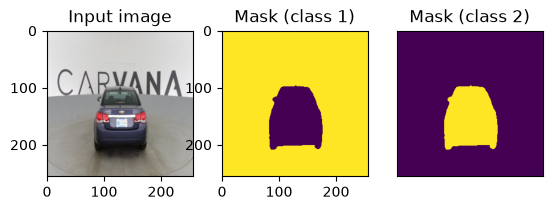

In [12]:
net=UNet(num_class=2).to(DEVICE)
state_dict=torch.load(os.path.join(model_save_root,"UNet.pth"), map_location=DEVICE)
mask_values = state_dict.pop('mask_values', [0, 1])
net.load_state_dict(state_dict)
net.eval()

transform = transforms.Compose([
            transforms.Resize((256, 256)),   
            transforms.ToTensor()           
            ])

test_imgs_list=os.listdir(test_hq_path)[0:1]

for i, filename in enumerate(test_imgs_list):
    img_path = os.path.join(test_hq_path, filename)
    img = Image.open(img_path).convert("RGB")
    img=transform(img)
    img = img.unsqueeze(0)
    img = img.to(device=DEVICE, dtype=torch.float32)

    mask=None

    with torch.no_grad():
        output = net(img).cpu()
        if net.num_class > 1:
            mask = output.argmax(dim=1)
        else:
            mask = torch.sigmoid(output) > 0.5

    mask=mask[0].long().squeeze().numpy()

    plot_img_and_mask(img, mask)